In [ ]:
pip install tqdm

第一區段

In [ ]:
import pandas as pd
import time
import numpy as np
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings("ignore")

# -----------------------------
# 1. 載入 Adult Train / Test
# -----------------------------
TRAIN_URL = "http://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
TEST_URL = "http://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test"

col_names = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

print("正在載入 adult.train.txt ...")
train_df = pd.read_csv(TRAIN_URL, header=None, names=col_names, na_values="?", skipinitialspace=True)

print("正在載入 adult.test.txt ...")
test_df = pd.read_csv(TEST_URL, header=0, names=col_names, na_values="?", skipinitialspace=True)

print(f"訓練集筆數: {len(train_df)}, 測試集筆數: {len(test_df)}")

# -----------------------------
# 2. 清理資料
# -----------------------------
train_df.dropna(inplace=True)
test_df.dropna(inplace=True)

# test 的 income 後面有小數點，要去掉
test_df["income"] = test_df["income"].str.replace(".", "", regex=False)

y_train = train_df["hours-per-week"]
y_test = test_df["hours-per-week"]

X_train = train_df.drop(columns=["hours-per-week"])
X_test = test_df.drop(columns=["hours-per-week"])

# 移除不想用的欄位
drop_cols = ["fnlwgt", "education"]
X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X_train.select_dtypes(include=["object"]).columns

# -----------------------------
# 3. 前處理
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

print("\n正在預處理資料...")
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print("預處理完成。\n")

# -----------------------------
# 4. 定義 timeline 函式
# -----------------------------
def make_timeline(train_t, pred_t):
    return f"[Train: {train_t:.2f} sec] → [Predict: {pred_t:.2f} sec]"

# -----------------------------
# 5. 模型訓練
# -----------------------------
models = {
    "KNN": KNeighborsRegressor(),
    "SVR": SVR(),
    "RandomForest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1)
}

results = []

for name, model in tqdm(list(models.items()), desc="模型訓練進度", ncols=100):

    print(f"\n正在訓練 {name}...")

    # 訓練
    start_train = time.time()
    model.fit(X_train_processed, y_train)
    train_time = time.time() - start_train

    # 預測
    start_pred = time.time()
    y_pred = model.predict(X_test_processed)
    predict_time = time.time() - start_pred

    total_time = train_time + predict_time

    # 評估指標
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # timeline
    timeline = make_timeline(train_time, predict_time)

    # 紀錄結果
    results.append({
        "Algorithm": name,
        "MAPE": mape,
        "RMSE": rmse,
        "R² Score": r2,
        "Train Time (sec)": train_time,
        "Predict Time (sec)": predict_time,
        "Total Time (sec)": total_time,
    })

    print(f"{name} 完成，總耗時: {total_time:.2f} 秒")
    print("Timeline:", timeline)

# -----------------------------
# 6. 顯示結果
# -----------------------------
results_df = pd.DataFrame(results).sort_values(by="RMSE")
results_df = results_df.round(4)

print("\n=== 實驗結果（Markdown 格式） ===")
print(results_df.to_markdown(index=False))

from IPython.display import display
print("\n=== DataFrame ===")
display(results_df)


正在載入 adult.train.txt ...
正在載入 adult.test.txt ...
訓練集筆數: 32561, 測試集筆數: 16281

正在預處理資料...
預處理完成。



模型訓練進度:   0%|                                                           | 0/4 [00:00<?, ?it/s]


正在訓練 KNN...


模型訓練進度:  25%|████████████▊                                      | 1/4 [00:11<00:34, 11.64s/it]

KNN 完成，總耗時: 11.62 秒
Timeline: [Train: 0.01 sec] → [Predict: 11.61 sec]

正在訓練 SVR...


...

模型訓練進度:  75%|██████████████████████████████████████▎            | 3/4 [03:01<01:00, 60.25s/it]

RandomForest 完成，總耗時: 23.38 秒
Timeline: [Train: 23.02 sec] → [Predict: 0.35 sec]

正在訓練 XGBoost...


模型訓練進度: 100%|███████████████████████████████████████████████████| 4/4 [03:02<00:00, 45.66s/it]

XGBoost 完成，總耗時: 0.64 秒
Timeline: [Train: 0.59 sec] → [Predict: 0.05 sec]

=== 實驗結果（Markdown 格式） ===
| Algorithm    |   MAPE |    RMSE |   R² Score |   Train Time (sec) |   Predict Time (sec) |   Total Time (sec) |
|:-------------|-------:|--------:|-----------:|-------------------:|---------------------:|-------------------:|
| XGBoost      | 0.2602 | 10.4033 |     0.2562 |             0.5944 |               0.0465 |             0.6409 |
| SVR          | 0.2668 | 10.8096 |     0.1969 |            97.7921 |              49.1665 |           146.959  |
| KNN          | 0.28   | 11.116  |     0.1508 |             0.0093 |              11.6101 |            11.6193 |
| RandomForest | 0.279  | 11.2903 |     0.1239 |            23.0231 |               0.3525 |            23.3755 |

=== DataFrame ===


,Algorithm,MAPE,RMSE,R² Score,Train Time (sec),Predict Time (sec),Total Time (sec)
3,XGBoost,0.2602,10.4033,0.2562,0.5944,0.0465,0.6409
1,SVR,0.2668,10.8096,0.1969,97.7921,49.1665,146.9586
0,KNN,0.2800,11.1160,0.1508,0.0093,11.6101,11.6193
2,RandomForest,0.2790,11.2903,0.1239,23.0231,0.3525,23.3755


第二區段


所有函式庫匯入完成。

1. 正在載入資料 (Boston Housing)...
Using Colab cache for faster access to the 'boston-housing-dataset' dataset.

資料載入成功，df.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
None

遺失值總數: 120

前 5 筆資料：
    CRIM      ZN  INDUS   CHAS    NOX     RM     AGE    DIS  RAD  TAX 

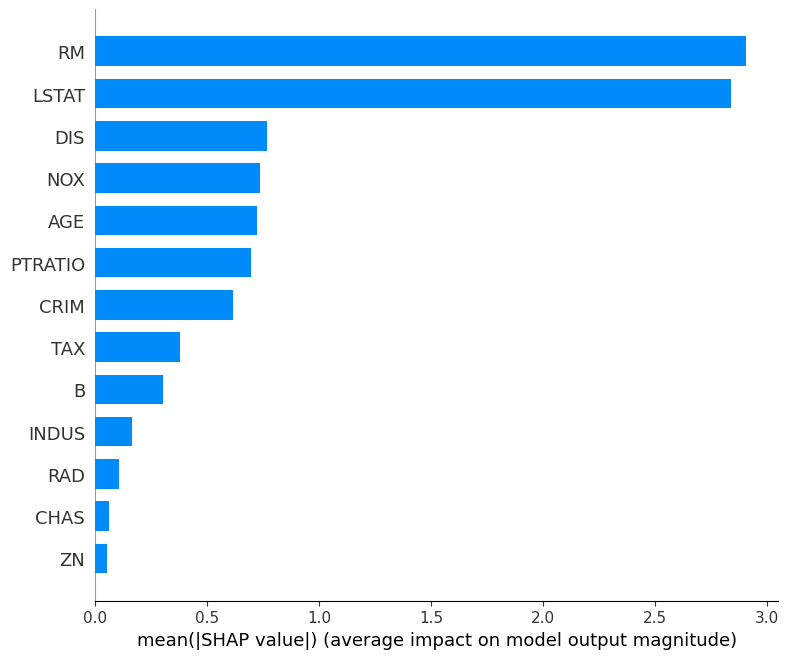


4. 使用 SHAP Top-N 特徵重新訓練並比較績效...

--- 使用前 7 個重要特徵重新訓練 ---
選用特徵： ['RM', 'LSTAT', 'DIS', 'NOX', 'AGE', 'PTRATIO', 'CRIM']
[Top 7] Fold 1: MAPE=0.1065, RMSE=2.6251, R2=0.9060
[Top 7] Fold 2: MAPE=0.1174, RMSE=3.2071, R2=0.8690
[Top 7] Fold 3: MAPE=0.1305, RMSE=3.7745, R2=0.8434
[Top 7] Fold 4: MAPE=0.1201, RMSE=3.1737, R2=0.9036
[Top 7] Fold 5: MAPE=0.0988, RMSE=2.9165, R2=0.8817
[Top 7] 平均績效：MAPE=0.1147, RMSE=3.1394, R2=0.8807


--- 使用前 5 個重要特徵重新訓練 ---
選用特徵： ['RM', 'LSTAT', 'DIS', 'NOX', 'AGE']
[Top 5] Fold 1: MAPE=0.1124, RMSE=2.7521, R2=0.8967
[Top 5] Fold 2: MAPE=0.1160, RMSE=3.2091, R2=0.8689
[Top 5] Fold 3: MAPE=0.1312, RMSE=3.9766, R2=0.8262
[Top 5] Fold 4: MAPE=0.1254, RMSE=3.5367, R2=0.8802
[Top 5] Fold 5: MAPE=0.1063, RMSE=3.1370, R2=0.8631
[Top 5] 平均績效：MAPE=0.1183, RMSE=3.3223, R2=0.8670


--- 使用前 3 個重要特徵重新訓練 ---
選用特徵： ['RM', 'LSTAT', 'DIS']
[Top 3] Fold 1: MAPE=0.1501, RMSE=3.5802, R2=0.8252
[Top 3] Fold 2: MAPE=0.1786, RMSE=4.5191, R2=0.7399
[Top 3] Fold 3: MAPE=0.1822, RMSE=

In [ ]:
# ==========================================================
# Boston Housing + XGBoost + SHAP 特徵重要性分析
# ==========================================================
!pip install "kagglehub[pandas-datasets]" shap xgboost

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
import warnings

# ----------------------------------------
# 設置
# ----------------------------------------
warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:,.4f}'.format
plt.rcParams["figure.figsize"] = (8, 6)
print("所有函式庫匯入完成。")

# ==========================================================
# 一些小工具函式
# ==========================================================
def build_model(random_state: int = 42) -> XGBRegressor:
    """建立 XGBoost Regressor 模型（統一參數方便維護）"""
    return XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=random_state,
        n_jobs=-1
    )


def cross_validate_model(X: pd.DataFrame,
                         y: pd.Series,
                         n_splits: int = 5,
                         random_state: int = 42,
                         verbose_prefix: str = ""):
    """
    對給定特徵 X / 標籤 y 進行 K-Fold Cross Validation，
    回傳平均 MAPE / RMSE / R2。
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = build_model(random_state=random_state)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        mape = mean_absolute_percentage_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        fold_results.append((mape, rmse, r2))
        print(f"{verbose_prefix}Fold {fold}: MAPE={mape:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}")

    avg_mape = np.mean([r[0] for r in fold_results])
    avg_rmse = np.mean([r[1] for r in fold_results])
    avg_r2 = np.mean([r[2] for r in fold_results])

    print(f"{verbose_prefix}平均績效：MAPE={avg_mape:.4f}, RMSE={avg_rmse:.4f}, R2={avg_r2:.4f}\n")

    return avg_mape, avg_rmse, avg_r2


# ==========================================================
# 1. 載入資料
# ==========================================================
print("\n1. 正在載入資料 (Boston Housing)...")

dataset_ref = "altavish/boston-housing-dataset"
file_path = "HousingData.csv"
pd_kwargs = {'encoding': 'utf-8'}

try:
    df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        dataset_ref,
        file_path,
        pandas_kwargs=pd_kwargs
    )

    print("\n資料載入成功，df.info():")
    print(df.info())

    print(f"\n遺失值總數: {df.isnull().sum().sum()}")
    print("\n前 5 筆資料：")
    print(df.head(5))

    X = df.drop('MEDV', axis=1)
    y = df['MEDV']

    print(f"\n資料剖析完成: {X.shape[0]} 筆樣本, {X.shape[1]} 個特徵")
    print("特徵欄位:", X.columns.tolist())

except Exception as e:
    raise RuntimeError(f"資料載入或處理失敗，後續程式不應繼續執行：{e}")


# ==========================================================
# 2. XGBoost + 5-Fold Cross Validation (全特徵)
# ==========================================================
print("\n2. 開始進行 XGBoost + 5-Fold Cross Validation（全特徵）...\n")

avg_mape_full, avg_rmse_full, avg_r2_full = cross_validate_model(
    X, y, n_splits=5, random_state=42, verbose_prefix="[全特徵] "
)


# ==========================================================
# 3. SHAP 特徵重要性分析
# ==========================================================
print("\n3. 開始 SHAP 特徵重要性分析...")

# 用全部資料重新訓練一個模型，專門拿來算 SHAP
model_all_data = build_model()
model_all_data.fit(X, y)

# 對 Tree model，TreeExplainer 通常更快更穩定
explainer = shap.TreeExplainer(model_all_data)
shap_values = explainer.shap_values(X)

# 特徵重要性：平均絕對 SHAP 值
feature_importance = np.abs(shap_values).mean(axis=0)
features_df = (
    pd.DataFrame({'Feature': X.columns, 'SHAP_Importance': feature_importance})
    .sort_values('SHAP_Importance', ascending=False)
    .reset_index(drop=True)
)

print("\nSHAP 特徵重要性排名 (平均絕對 SHAP 值)：")
print(features_df.to_markdown(index=False, floatfmt=",.4f"))

# Bar Plot
print("\n顯示 SHAP Bar Plot（特徵重要性）...")
shap.summary_plot(shap_values, X, plot_type="bar")
plt.show()


# ==========================================================
# 4. 依照 SHAP Top-N 特徵重新訓練 & 評估
# ==========================================================
TOP_N_LIST = [7, 5, 3]   # 想測哪些 Top-N 就改這裡

print("\n4. 使用 SHAP Top-N 特徵重新訓練並比較績效...")
results = []

for top_n in TOP_N_LIST:
    selected_features = features_df['Feature'].iloc[:top_n].tolist()
    print(f"\n--- 使用前 {top_n} 個重要特徵重新訓練 ---")
    print("選用特徵：", selected_features)

    X_sel = X[selected_features]

    avg_mape_sel, avg_rmse_sel, avg_r2_sel = cross_validate_model(
        X_sel, y, n_splits=5, random_state=42, verbose_prefix=f"[Top {top_n}] "
    )

    results.append({
        "版本": f"Top {top_n} 特徵",
        "MAPE": avg_mape_sel,
        "RMSE": avg_rmse_sel,
        "R²": avg_r2_sel
    })


# ==========================================================
# 5. 特徵刪減前後績效比較
# ==========================================================
print("\n5. 特徵刪減前後績效比較：")

compare_df = pd.DataFrame([{
    "版本": "全特徵",
    "MAPE": avg_mape_full,
    "RMSE": avg_rmse_full,
    "R²": avg_r2_full
}] + results)

print(compare_df.to_markdown(index=False, floatfmt=",.4f"))
